# Установка библиотек

In [13]:
!apt-get install -y xvfb python3-opengl ffmpeg > /dev/null 2>&1
!pip install gymnasium[classic_control] imageio[ffmpeg] pyvirtualdisplay > /dev/null 2>&1

   1% ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25,399/2,000,000  [ 0:04:17 < 13:05:10 , 42 it/s ]

# Импорт библиотек

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from IPython.display import Video
import imageio
from collections import deque
from tqdm import tqdm
from pyvirtualdisplay import Display

display = Display(visible=0, size=(1400, 900))
display.start()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
print(f"PyTorch версия: {torch.__version__}")

Устройство: cuda
PyTorch версия: 2.10.0+cu128


# Реализация нейронной сети Policy и Value

In [2]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()

        # Общая архитектура
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Policy head
        self.policy_head = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

        # Value head
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        x = self.shared(state)
        action_probs = self.policy_head(x)
        state_value = self.value_head(x)
        return action_probs, state_value

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        action_probs, state_value = self.forward(state)

        dist = Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        return action.item(), log_prob, state_value

# Реализация REINFORCE с baseline

In [3]:
class REINFORCEWithBaseline:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.policy = PolicyNetwork(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = gamma

        # Буферы
        self.log_probs = []
        self.rewards = []
        self.values = []

    def select_action(self, state):
        action, log_prob, state_value = self.policy.get_action(state)

        self.log_probs.append(log_prob)
        self.values.append(state_value)

        return action

    def store_reward(self, reward):
        self.rewards.append(reward)

    def finish_episode(self):
        # Вычисляем дисконтированные награды
        discounted_rewards = []
        cumulative = 0

        for reward in reversed(self.rewards):
            cumulative = reward + self.gamma * cumulative
            discounted_rewards.insert(0, cumulative)

        discounted_rewards = torch.FloatTensor(discounted_rewards).to(device)

        # Нормализация
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-8)

        # Преимущества
        values = torch.cat(self.values).squeeze().to(device)
        advantages = discounted_rewards - values.detach()

        # Вычисляем потери
        policy_loss = torch.stack([-log_p * adv for log_p, adv in zip(self.log_probs, advantages)]).sum()
        value_loss = torch.stack([F.mse_loss(val, rew) for val, rew in zip(values, discounted_rewards)]).sum()

        total_loss = policy_loss + value_loss

        # Оптимизация
        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=1.0)
        self.optimizer.step()

        # Очистка
        self.log_probs = []
        self.rewards = []
        self.values = []

        return total_loss.item()

    def save(self, path):
        torch.save(self.policy.state_dict(), path)

    def load(self, path):
        self.policy.load_state_dict(torch.load(path, map_location=device))

# Обучение агента

In [4]:
# Параметры
ENV_NAME = "Acrobot-v1"
EPISODES = 1500  # Можно уменьшить до 1000 для скорости
TARGET_REWARD = -100

# Создаем среду
env = gym.make(ENV_NAME)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Создаем агента
agent = REINFORCEWithBaseline(
    state_dim=state_dim,
    action_dim=action_dim,
    lr=1e-3,
    gamma=0.99
)

# Для статистики
episode_rewards = []
episode_lengths = []
moving_avg = []
best_reward = -float('inf')

print("=" * 60)
print(f"Обучение REINFORCE с baseline на {ENV_NAME}")
print(f"Цель: средняя награда >= {TARGET_REWARD}")
print("=" * 60)

for episode in range(1, EPISODES + 1):
    state, _ = env.reset()
    episode_reward = 0
    step = 0
    done = False

    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.store_reward(reward)

        state = next_state
        episode_reward += reward
        step += 1

        if step > 1000:
            break

    episode_rewards.append(episode_reward)
    episode_lengths.append(step)

    # Обновляем политику
    loss = agent.finish_episode()

    # Сохраняем лучшую модель
    if episode_reward > best_reward:
        best_reward = episode_reward
        agent.save("best_reinforce_acrobot.pth")

    # Вычисляем скользящее среднее
    if len(episode_rewards) >= 100:
        avg_reward = np.mean(episode_rewards[-100:])
        moving_avg.append(avg_reward)
    else:
        avg_reward = np.mean(episode_rewards)
        moving_avg.append(avg_reward)

    # Вывод прогресса (каждые 50 эпизодов)
    if episode % 50 == 0:
        print(f"Эпизод {episode:4d} | Награда: {episode_reward:7.2f} | "
              f"Ср.(100): {avg_reward:7.2f} | Лучшая: {best_reward:7.2f} | "
              f"Шаги: {step:3d} | Loss: {loss:.4f}")

        # Проверка цели
        if avg_reward >= TARGET_REWARD:
            print(f"\n Достигнута целевая награда {TARGET_REWARD} на эпизоде {episode}!")
            print(f"Средняя награда за последние 100 эпизодов: {avg_reward:.2f}")
            break

env.close()

print("\n" + "=" * 60)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Финальная средняя награда (последние 100): {np.mean(episode_rewards[-100:]):.2f}")
print(f"Лучшая награда: {best_reward:.2f}")
print("=" * 60)

Обучение REINFORCE с baseline на Acrobot-v1
Цель: средняя награда >= -100
Эпизод   50 | Награда: -500.00 | Ср.(100): -500.00 | Лучшая: -500.00 | Шаги: 500 | Loss: 423.9005
Эпизод  100 | Награда: -183.00 | Ср.(100): -484.92 | Лучшая: -183.00 | Шаги: 184 | Loss: 2.7415
Эпизод  150 | Награда: -392.00 | Ср.(100): -417.11 | Лучшая: -177.00 | Шаги: 393 | Loss: 50.1024
Эпизод  200 | Награда: -207.00 | Ср.(100): -314.90 | Лучшая: -167.00 | Шаги: 208 | Loss: -6.9923
Эпизод  250 | Награда: -257.00 | Ср.(100): -245.14 | Лучшая: -138.00 | Шаги: 258 | Loss: 544.5479
Эпизод  300 | Награда: -500.00 | Ср.(100): -202.58 | Лучшая: -112.00 | Шаги: 500 | Loss: 2479.6399
Эпизод  350 | Награда:  -96.00 | Ср.(100): -164.70 | Лучшая:  -91.00 | Шаги:  97 | Loss: -4.3135
Эпизод  400 | Награда: -102.00 | Ср.(100): -141.78 | Лучшая:  -87.00 | Шаги: 103 | Loss: 0.7978
Эпизод  450 | Награда:  -78.00 | Ср.(100): -123.22 | Лучшая:  -78.00 | Шаги:  79 | Loss: -1.5541
Эпизод  500 | Награда:  -83.00 | Ср.(100): -109.68 

#  Визуализация

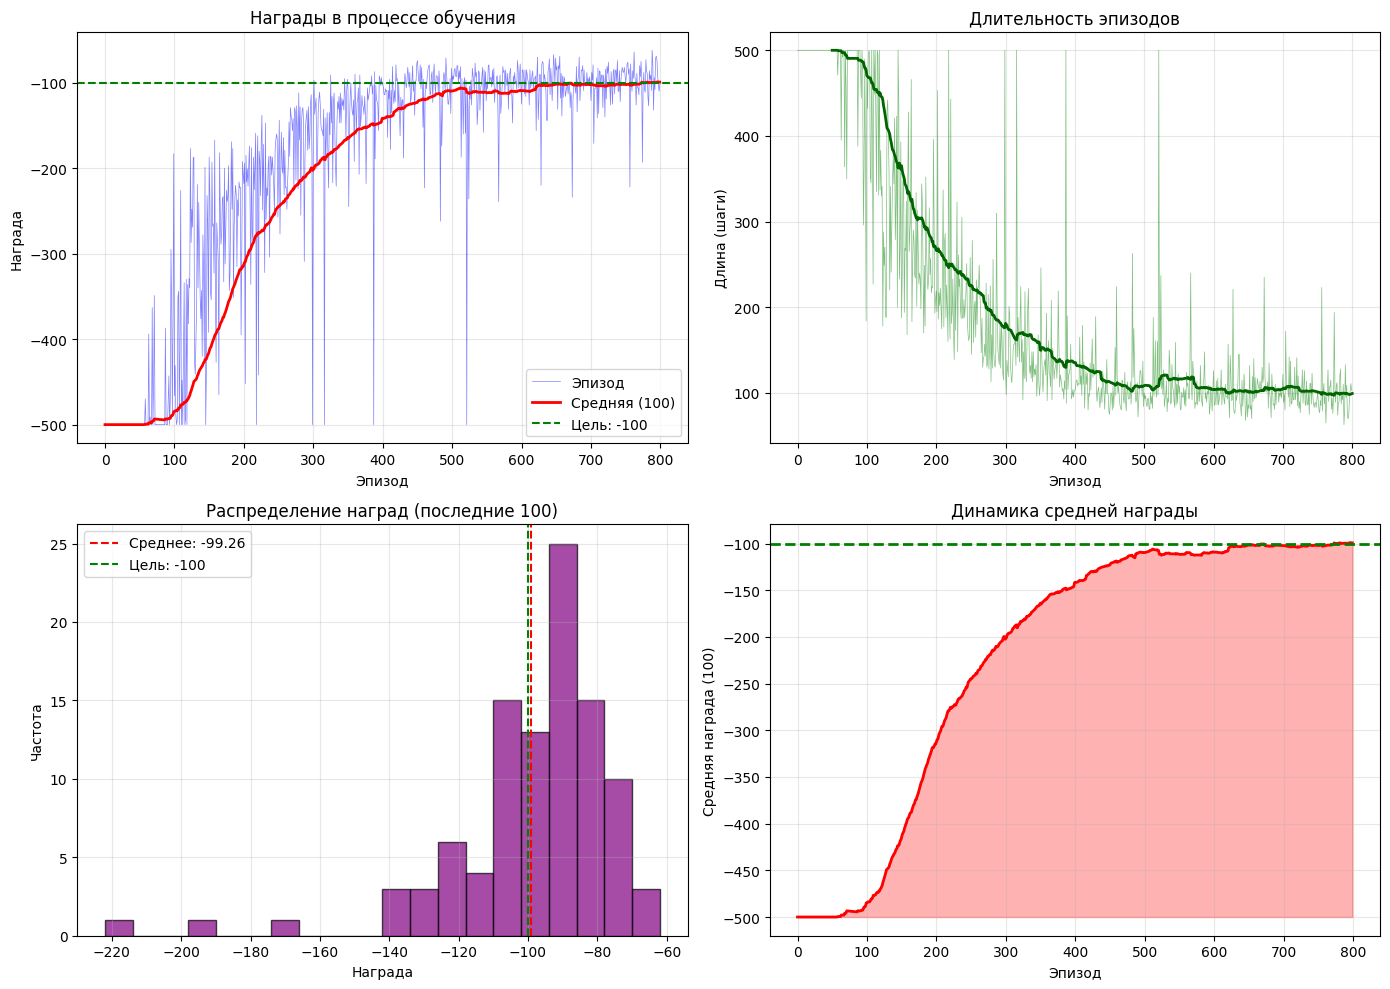


 ФИНАЛЬНАЯ СТАТИСТИКА:
----------------------------------------
Всего эпизодов: 800
Средняя награда (все): -195.54
Средняя награда (посл.100): -99.26
Лучшая награда: -62.00
Средняя длина: 196.4 шагов


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График наград
axes[0, 0].plot(episode_rewards, alpha=0.5, label='Эпизод', color='blue', linewidth=0.5)
axes[0, 0].plot(moving_avg, label='Средняя (100)', color='red', linewidth=2)
axes[0, 0].axhline(y=TARGET_REWARD, color='g', linestyle='--', label=f'Цель: {TARGET_REWARD}')
axes[0, 0].set_xlabel('Эпизод')
axes[0, 0].set_ylabel('Награда')
axes[0, 0].set_title('Награды в процессе обучения')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График длин
axes[0, 1].plot(episode_lengths, alpha=0.5, color='green', linewidth=0.5)
if len(episode_lengths) >= 50:
    ma_length = np.convolve(episode_lengths, np.ones(50)/50, mode='valid')
    axes[0, 1].plot(range(50, len(episode_lengths)+1), ma_length, color='darkgreen', linewidth=2)
axes[0, 1].set_xlabel('Эпизод')
axes[0, 1].set_ylabel('Длина (шаги)')
axes[0, 1].set_title('Длительность эпизодов')
axes[0, 1].grid(True, alpha=0.3)

# Гистограмма
if len(episode_rewards) >= 100:
    axes[1, 0].hist(episode_rewards[-100:], bins=20, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 0].axvline(x=np.mean(episode_rewards[-100:]), color='r', linestyle='--',
                       label=f'Среднее: {np.mean(episode_rewards[-100:]):.2f}')
    axes[1, 0].axvline(x=TARGET_REWARD, color='g', linestyle='--', label=f'Цель: {TARGET_REWARD}')
    axes[1, 0].set_xlabel('Награда')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 0].set_title('Распределение наград (последние 100)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Прогресс средней награды
axes[1, 1].plot(moving_avg, color='red', linewidth=2)
axes[1, 1].fill_between(range(len(moving_avg)), -500, moving_avg, alpha=0.3, color='red')
axes[1, 1].axhline(y=TARGET_REWARD, color='g', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Эпизод')
axes[1, 1].set_ylabel('Средняя награда (100)')
axes[1, 1].set_title('Динамика средней награды')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика
print("\n ФИНАЛЬНАЯ СТАТИСТИКА:")
print("-" * 40)
print(f"Всего эпизодов: {len(episode_rewards)}")
print(f"Средняя награда (все): {np.mean(episode_rewards):.2f}")
print(f"Средняя награда (посл.100): {np.mean(episode_rewards[-100:]):.2f}")
print(f"Лучшая награда: {np.max(episode_rewards):.2f}")
print(f"Средняя длина: {np.mean(episode_lengths):.1f} шагов")

# Видеодемонстрация

In [6]:
def create_demo_video(agent, env_name, video_path, episodes=2):
    env = gym.make(env_name, render_mode="rgb_array")
    frames = []
    total_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        step = 0
        episode_frames = []

        while not done and step < 1000:
            frame = env.render()
            episode_frames.append(frame)

            action, _, _ = agent.policy.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state = next_state
            episode_reward += reward
            step += 1

        total_rewards.append(episode_reward)
        frames.extend(episode_frames)
        print(f"Демо {ep+1}: Награда = {episode_reward:.2f}, Шагов = {step}")

    env.close()

    with imageio.get_writer(video_path, fps=30, codec='libx264') as writer:
        for frame in frames:
            writer.append_data(frame)

    return video_path, total_rewards

# Загружаем лучшую модель
print("Загрузка лучшей модели...")
try:
    agent.load("best_reinforce_acrobot.pth")
    print(" Модель загружена")
except:
    print(" Модель не найдена, используем текущую")

print("\nСоздание видео...")
video_path, demo_rewards = create_demo_video(agent, ENV_NAME, "acrobot_demo.mp4", episodes=2)

Video(video_path, embed=True, width=800, height=600)

Загрузка лучшей модели...
 Модель загружена

Создание видео...
Демо 1: Награда = -104.00, Шагов = 105


Демо 2: Награда = -63.00, Шагов = 64


# Тестирование

In [8]:
def test_random_policy(env_name, n_episodes=10):
    env = gym.make(env_name)
    rewards = []

    for _ in range(n_episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

        rewards.append(episode_reward)

    env.close()
    return np.mean(rewards), np.std(rewards)

print("Тестирование случайной политики...")
random_mean, random_std = test_random_policy(ENV_NAME)
print(f"Случайная политика: {random_mean:.2f} ± {random_std:.2f}")

print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 60)
final_avg = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
print(f"REINFORCE с baseline: {final_avg:.2f} ± {np.std(episode_rewards[-100:]):.2f}")
print(f"Случайная политика:   {random_mean:.2f} ± {random_std:.2f}")
print(f"Улучшение: {abs(final_avg - random_mean):.2f} пунктов")

if final_avg >= TARGET_REWARD:
    print(f"\n ЦЕЛЬ ДОСТИГНУТА! Средняя награда {final_avg:.2f} >= {TARGET_REWARD}")
else:
    print(f"\n Цель не достигнута. Средняя награда {final_avg:.2f} < {TARGET_REWARD}")

Тестирование случайной политики...
Случайная политика: -500.00 ± 0.00

ИТОГОВОЕ СРАВНЕНИЕ
REINFORCE с baseline: -99.26 ± 23.95
Случайная политика:   -500.00 ± 0.00
Улучшение: 400.74 пунктов

 ЦЕЛЬ ДОСТИГНУТА! Средняя награда -99.26 >= -100
